# 03 · O que a redação revela

**Pergunta:** como se distribuem as notas da redação, por que tantas valem zero e qual
competência mais derruba os participantes?

A redação vale 0–1000, soma de 5 competências de 0–200 (passos de 40). O status
(`TP_STATUS_REDACAO`) registra o motivo quando a prova é anulada ou zerada.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from enem2024 import labels, plots
from enem2024.data import load

plots.setup()
GRAY = plots.BASELINE  # de-ênfase


## Por que uma redação vale zero?

findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


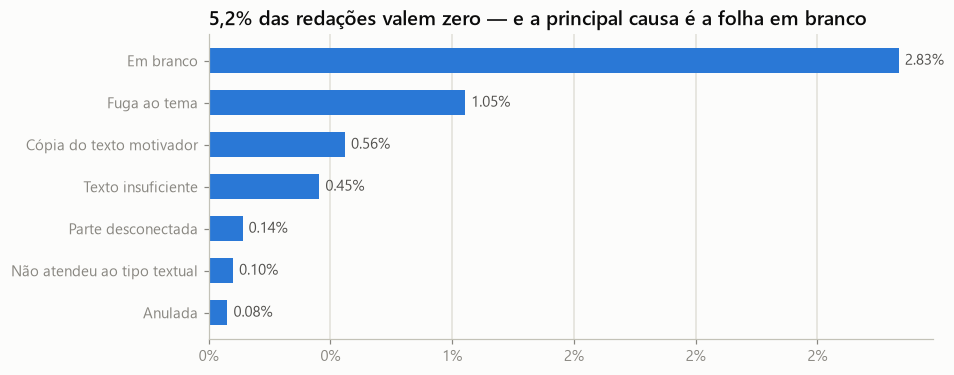

Redações avaliadas sem problemas: 94.8%


In [2]:
rs = load("redacao_status")
total = rs["n"].sum()
zeros = rs[rs.status != 1].copy()
zeros["motivo"] = zeros["status"].map(labels.STATUS_REDACAO)
zeros["pct"] = zeros["n"] / total
zeros = zeros.sort_values("pct")

fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.barh(zeros["motivo"], zeros["pct"], color=plots.BLUE, height=0.6)
ax.bar_label(ax.containers[0], fmt=lambda v: f"{v:.2%}", padding=4,
             fontsize=9.5, color=plots.INK_SECONDARY)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title("5,2% das redações valem zero — e a principal causa é a folha em branco")
ax.grid(axis="y", visible=False)
plt.show()

print(f"Redações avaliadas sem problemas: {rs.loc[rs.status == 1, 'n'].sum() / total:.1%}")

## A distribuição das notas

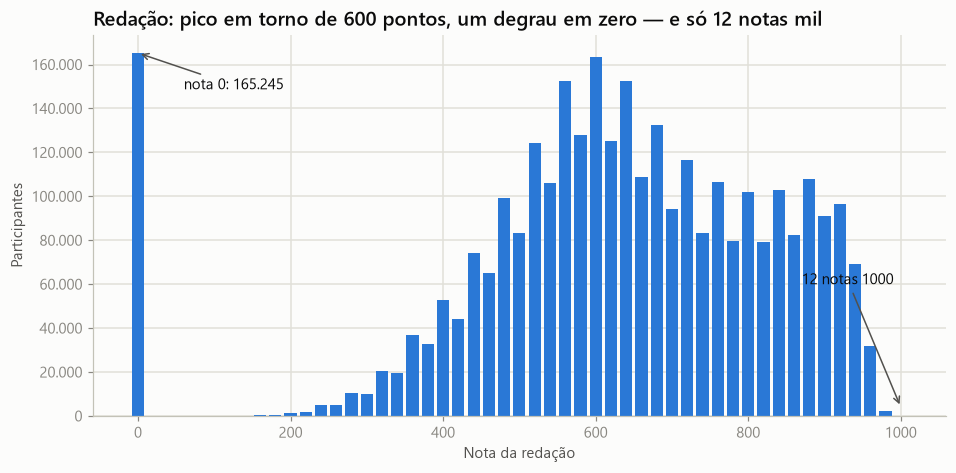

Notas >= 900: 291.123


In [3]:
rd = load("redacao_dist")
dist = rd.groupby("nota")["n"].sum().sort_index()
n1000 = int(dist.get(1000, 0))
n900 = int(dist[dist.index >= 900].sum())

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(dist.index, dist.values, width=16, color=plots.BLUE)
ax.yaxis.set_major_formatter(plt.FuncFormatter(plots.fmt_thousands))
ax.set_title("Redação: pico em torno de 600 pontos, um degrau em zero — e só 12 notas mil")
ax.set_xlabel("Nota da redação")
ax.set_ylabel("Participantes")
ax.annotate(f"{n1000} notas 1000", xy=(1000, 4000), xytext=(870, 60000),
            fontsize=10, color=plots.INK,
            arrowprops=dict(arrowstyle="->", color=plots.INK_SECONDARY, lw=1))
ax.annotate(f"nota 0: {dist.get(0, 0):,.0f}".replace(",", "."),
            xy=(0, dist.get(0, 0)), xytext=(60, dist.get(0, 0) * 0.9),
            fontsize=10, color=plots.INK,
            arrowprops=dict(arrowstyle="->", color=plots.INK_SECONDARY, lw=1))
plots.save_fig(fig, "06_redacao_dist")
plt.show()

print(f"Notas >= 900: {n900:,}".replace(",", "."))

## Qual competência mais derruba?

Somente redações avaliadas sem problemas (status 1). C2 = compreender o tema; C5 = proposta de intervenção.

findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


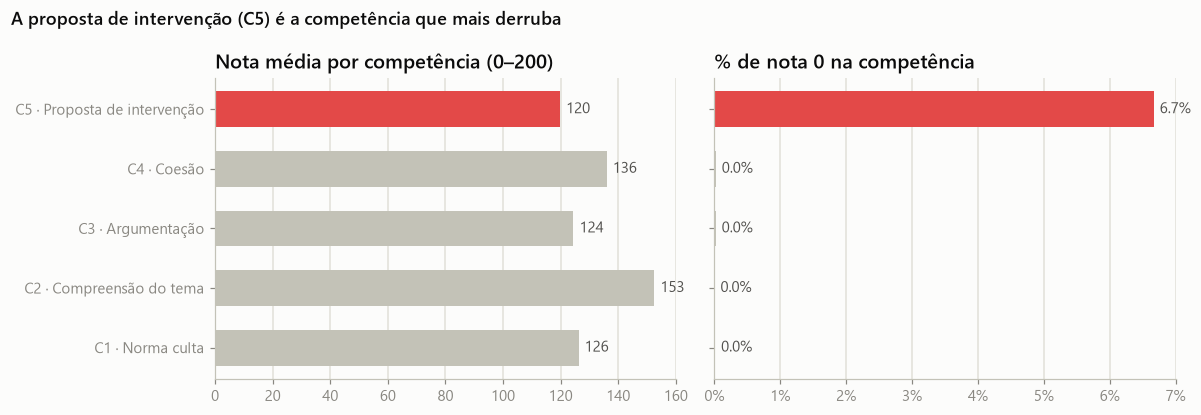

In [4]:
rc = load("redacao_competencias")
media = (rc.nota * rc.n).groupby(rc.competencia).sum() / rc.groupby("competencia")["n"].sum()
# reindex: uma competência sem nenhuma nota 0 (caso da C2) deve aparecer como 0%
p_zero = (
    rc[rc.nota == 0].set_index("competencia")["n"] / rc.groupby("competencia")["n"].sum()
).reindex(media.index).fillna(0)
nomes = [labels.COMPETENCIAS_REDACAO[c] for c in media.index]
pior = media.idxmin()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
cores = [plots.RED if c == pior else GRAY for c in media.index]
axes[0].barh(nomes, media.values, color=cores, height=0.6)
axes[0].bar_label(axes[0].containers[0], fmt="%.0f", padding=4, fontsize=9.5,
                  color=plots.INK_SECONDARY)
axes[0].set_title("Nota média por competência (0–200)")
axes[0].grid(axis="y", visible=False)

axes[1].barh(nomes, p_zero.values, color=cores, height=0.6)
axes[1].bar_label(axes[1].containers[0], fmt=lambda v: f"{v:.1%}", padding=4,
                  fontsize=9.5, color=plots.INK_SECONDARY)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[1].set_title("% de nota 0 na competência")
axes[1].set_yticklabels([])
axes[1].grid(axis="y", visible=False)

fig.suptitle("A proposta de intervenção (C5) é a competência que mais derruba",
             x=0.01, ha="left", fontweight="semibold")
fig.tight_layout()
plots.save_fig(fig, "07_competencias")
plt.show()

## Público × privada na redação

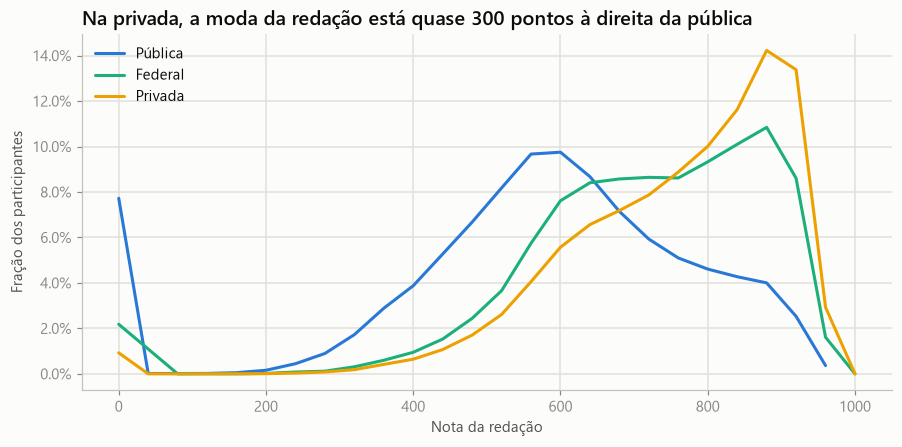

In [5]:
rd2 = load("redacao_dist")
rd2 = rd2.assign(grupo=rd2["dependencia"].map({1: "Federal", 2: "Pública", 3: "Pública", 4: "Privada"}))
rd2 = rd2.dropna(subset=["grupo"])
# as notas concentram em múltiplos de 40 (soma de 5 competências em passos de 40);
# bins de 40 evitam o serrilhado artificial
rd2["faixa"] = (rd2["nota"] // 40) * 40

fig, ax = plt.subplots(figsize=(9.5, 4.2))
for nome, cor in zip(["Pública", "Federal", "Privada"], plots.CATEGORICAL[:3]):
    d = rd2[rd2.grupo == nome].groupby("faixa")["n"].sum().sort_index()
    ax.plot(d.index, d / d.sum(), color=cor, label=nome, linewidth=2)
ax.set_title("Na privada, a moda da redação está quase 300 pontos à direita da pública")
ax.set_xlabel("Nota da redação")
ax.set_ylabel("Fração dos participantes")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1%}"))
ax.legend()
plots.save_fig(fig, "08_redacao_pub_priv")
plt.show()

## Conclusões

1. **94,8% das redações foram avaliadas normalmente**; 5,2% valem zero, e o principal motivo
   é a **folha em branco (2,8% do total)** — mais que fuga ao tema (1,1%) e cópia (0,6%) somadas.
2. A média nacional foi **~625 pontos**; 291 mil participantes passaram de 900, mas apenas
   **12 alcançaram a nota 1000**.
3. **C5 (proposta de intervenção) é a competência que mais derruba** (média ~120), enquanto
   C2 (compreensão do tema) é a mais alta (~152). Treinar a estrutura da intervenção é o maior
   retorno por hora de estudo.
4. O gap público × privada é **maior na redação (192 pontos)** do que em qualquer prova objetiva.